# Credit Card Fraud Detection
### Machine Learning Project

**Dataset:** [Kaggle - Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

**Steps Covered:**
1. Import Libraries
2. Load Dataset
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing
5. Model Training (Logistic Regression + Random Forest + Gradient Boosting)
6. Comprehensive Performance Comparison
7. Visualizations
8. Testing with New Samples

## Import Libraries

In [1]:
# Import core data handling and visualisation libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Model imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score,
    matthews_corrcoef, cohen_kappa_score,
    log_loss
)

# Statistical tests
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

# Set global plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("All libraries imported successfully.")

All libraries imported successfully.


## Load Dataset

In [2]:
# Load the dataset
df = pd.read_csv('creditcard.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (284807, 31)

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# Basic info about the dataset
print("Dataset Info:")
print("-------------")
print(f"Total Transactions : {df.shape[0]}")
print(f"Total Features     : {df.shape[1]}")
print(f"\nFraud Cases        : {df['Class'].sum()} ({df['Class'].mean()*100:.2f}%)")
print(f"Legitimate Cases   : {(df['Class']==0).sum()} ({(df['Class']==0).mean()*100:.2f}%)")
print("\nMissing Values:", df.isnull().sum().sum())

Dataset Info:
-------------
Total Transactions : 284807
Total Features     : 31

Fraud Cases        : 492 (0.17%)
Legitimate Cases   : 284315 (99.83%)

Missing Values: 0


## Exploratory Data Analysis (EDA)

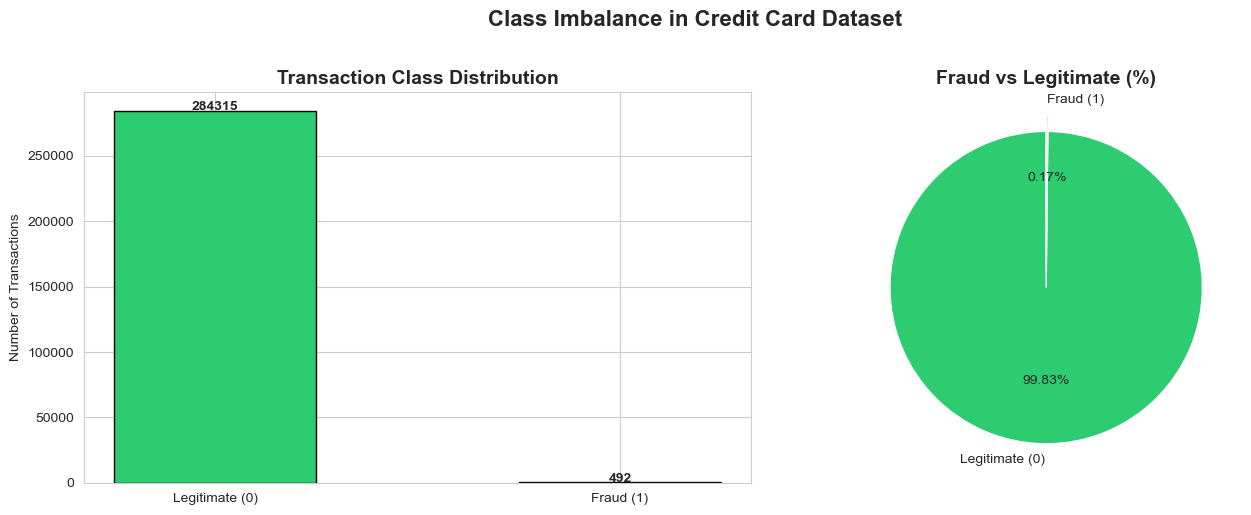

Observation: The dataset is highly imbalanced — only ~0.17% are fraud cases.


In [4]:
# ---- Plot 1: Class Distribution (Fraud vs Legitimate) ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts = df['Class'].value_counts()
labels = ['Legitimate (0)', 'Fraud (1)']
colors = ['#2ecc71', '#e74c3c']

# Bar chart
axes[0].bar(labels, class_counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Transaction Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 500, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=labels, autopct='%1.2f%%',
            colors=colors, startangle=90, explode=(0, 0.1))
axes[1].set_title('Fraud vs Legitimate (%)', fontsize=14, fontweight='bold')

plt.suptitle('Class Imbalance in Credit Card Dataset', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("Observation: The dataset is highly imbalanced — only ~0.17% are fraud cases.")

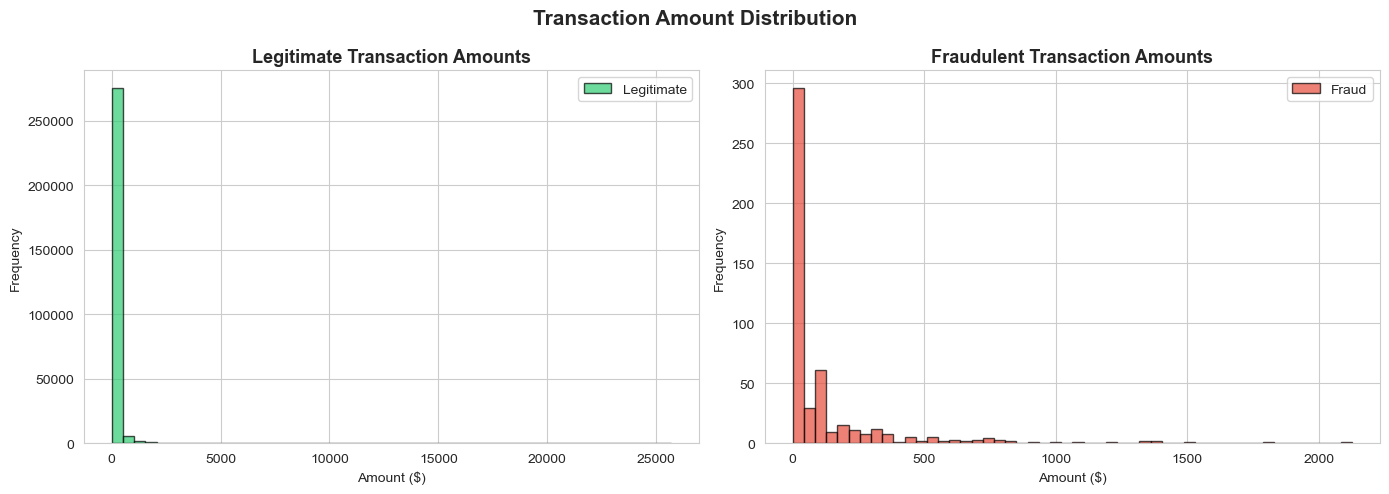

Average Legitimate Amount : $88.29
Average Fraud Amount      : $122.21


In [5]:
# ---- Plot 2: Transaction Amount Distribution ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Separate fraud and legitimate amounts
fraud = df[df['Class'] == 1]['Amount']
legit = df[df['Class'] == 0]['Amount']

# Legitimate transaction amounts histogram
axes[0].hist(legit, bins=50, color='#2ecc71', alpha=0.7, label='Legitimate', edgecolor='black')
axes[0].set_title('Legitimate Transaction Amounts', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Fraud transaction amounts histogram
axes[1].hist(fraud, bins=50, color='#e74c3c', alpha=0.7, label='Fraud', edgecolor='black')
axes[1].set_title('Fraudulent Transaction Amounts', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Amount ($)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('Transaction Amount Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Average Legitimate Amount : ${legit.mean():.2f}")
print(f"Average Fraud Amount      : ${fraud.mean():.2f}")

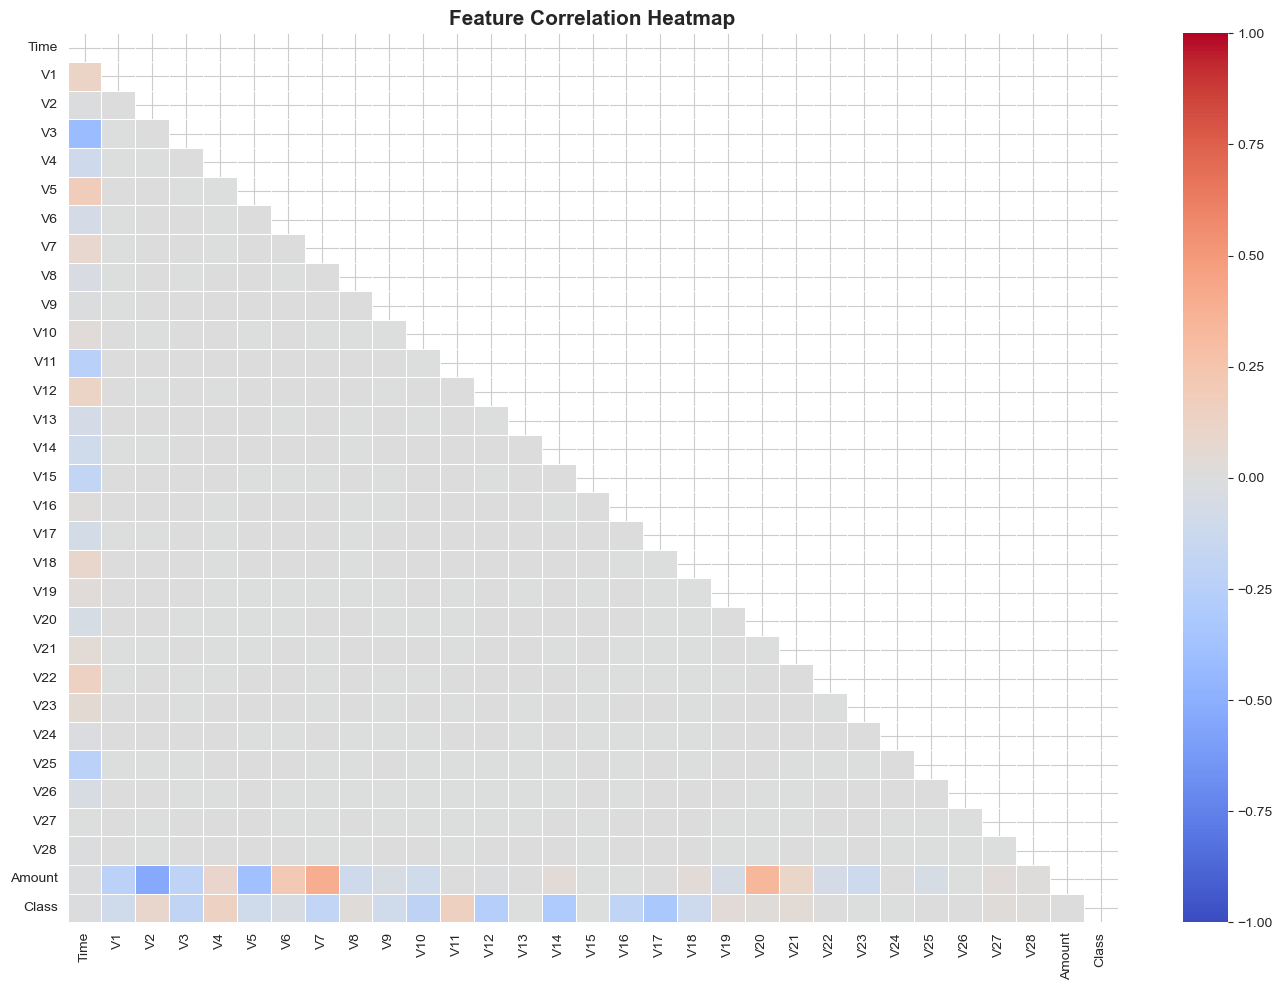

In [6]:
# ---- Plot 3: Feature Correlation Heatmap ----
# Shows how strongly each feature is correlated with others
# Upper triangle is masked to avoid redundancy
plt.figure(figsize=(14, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))   # mask upper triangle
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Data Preprocessing

In [7]:
# Scale 'Amount' and 'Time' columns (V1-V28 are already PCA-scaled)
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled']   = scaler.fit_transform(df[['Time']])

# Drop original Amount and Time columns since we now have scaled versions
df_processed = df.drop(columns=['Amount', 'Time'])

print("Scaling done.")
print("New shape:", df_processed.shape)

Scaling done.
New shape: (284807, 31)


In [8]:
# Handle class imbalance using undersampling
# The dataset has ~284k legitimate vs ~492 fraud — a massive imbalance
fraud_df = df_processed[df_processed['Class'] == 1]
legit_df  = df_processed[df_processed['Class'] == 0]

# Undersample legitimate transactions to match the fraud count
legit_sample = legit_df.sample(n=len(fraud_df), random_state=42)

# Combine fraud and sampled legitimate, then shuffle
balanced_df = pd.concat([fraud_df, legit_sample]).sample(frac=1, random_state=42)

print(f"Balanced Dataset Size : {balanced_df.shape[0]}")
print(f"Fraud Samples         : {balanced_df['Class'].sum()}")
print(f"Legitimate Samples    : {(balanced_df['Class']==0).sum()}")

Balanced Dataset Size : 984
Fraud Samples         : 492
Legitimate Samples    : 492


In [9]:
# Split features and target
X = balanced_df.drop(columns=['Class'])   # all feature columns
y = balanced_df['Class']                  # target: 0 = legitimate, 1 = fraud

# Train-Test Split (80% train, 20% test)
# stratify=y ensures both splits maintain the 50/50 class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")

Training samples : 787
Testing samples  : 197


## Model Training

In [10]:
# Model 1: Logistic Regression
# A linear model that estimates the probability of fraud using a sigmoid function
# C=0.1 applies stronger regularisation to prevent overfitting
lr_model = LogisticRegression(max_iter=1000, C=0.1, random_state=42)
lr_model.fit(X_train, y_train)

# Predict class labels and fraud probabilities on the test set
lr_pred  = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]   # probability of class 1 (fraud)

print("=== Logistic Regression ===")
print(f"Accuracy : {accuracy_score(y_test, lr_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred, target_names=['Legitimate', 'Fraud']))

=== Logistic Regression ===
Accuracy : 93.40%

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.92      0.95      0.94        99
       Fraud       0.95      0.92      0.93        98

    accuracy                           0.93       197
   macro avg       0.93      0.93      0.93       197
weighted avg       0.93      0.93      0.93       197



In [11]:
# Model 2: Random Forest
# An ensemble of decision trees — robust to overfitting and handles non-linear patterns well
rf_model = RandomForestClassifier(
    n_estimators=200,       # number of trees in the forest
    max_depth=None,         # trees grow until all leaves are pure
    min_samples_split=2,    # minimum samples required to split a node
    min_samples_leaf=1,     # minimum samples required at each leaf node
    max_features='sqrt',    # use sqrt(n_features) at each split for tree diversity
    random_state=42,
    n_jobs=-1               # use all available CPU cores
)
rf_model.fit(X_train, y_train)

# Predict on test set
rf_pred  = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(f"Accuracy : {accuracy_score(y_test, rf_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=['Legitimate', 'Fraud']))

=== Random Forest ===
Accuracy : 93.91%

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.92      0.96      0.94        99
       Fraud       0.96      0.92      0.94        98

    accuracy                           0.94       197
   macro avg       0.94      0.94      0.94       197
weighted avg       0.94      0.94      0.94       197



In [12]:
# Model 3: Gradient Boosting
# Builds trees sequentially — each new tree corrects the residual errors of the previous one
# Generally stronger than a single tree and often competitive with Random Forest
gb_model = GradientBoostingClassifier(
    n_estimators=150,       # number of boosting stages (trees)
    max_depth=5,            # maximum depth of each individual tree
    learning_rate=0.1,      # shrinkage factor — controls how much each tree contributes
    subsample=0.8,          # fraction of samples used per tree (reduces overfitting)
    random_state=42
)
gb_model.fit(X_train, y_train)

# Predict on test set
gb_pred  = gb_model.predict(X_test)
gb_proba = gb_model.predict_proba(X_test)[:, 1]

print("=== Gradient Boosting ===")
print(f"Accuracy : {accuracy_score(y_test, gb_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, gb_pred, target_names=['Legitimate', 'Fraud']))

=== Gradient Boosting ===
Accuracy : 94.42%

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.93      0.96      0.95        99
       Fraud       0.96      0.93      0.94        98

    accuracy                           0.94       197
   macro avg       0.94      0.94      0.94       197
weighted avg       0.94      0.94      0.94       197



## Comprehensive Performance Comparison

In [13]:
# Compute all evaluation metrics for a given model
def compute_metrics(y_true, y_pred, y_proba, model_name):
    n     = len(y_true)
    acc   = accuracy_score(y_true, y_pred)
    prec  = precision_score(y_true, y_pred)
    rec   = recall_score(y_true, y_pred)
    f1    = f1_score(y_true, y_pred)
    auc   = roc_auc_score(y_true, y_proba)
    mcc   = matthews_corrcoef(y_true, y_pred)       # ranges -1 to +1, +1 is perfect
    kappa = cohen_kappa_score(y_true, y_pred)       # agreement beyond chance
    ll    = log_loss(y_true, y_proba)               # penalises confident wrong predictions

    # Z-score: two-proportion z-test (model accuracy vs random baseline of 0.5)
    p0 = 0.5
    z_score = (acc - p0) / np.sqrt(p0 * (1 - p0) / n)

    return {
        'Model'         : model_name,
        'Accuracy'      : round(acc  * 100, 4),
        'Precision'     : round(prec * 100, 4),
        'Recall'        : round(rec  * 100, 4),
        'F1 Score'      : round(f1   * 100, 4),
        'AUC-ROC'       : round(auc,         4),
        'MCC'           : round(mcc,          4),
        "Cohen's Kappa" : round(kappa,        4),
        'Log Loss'      : round(ll,           4),
        'Z-Score'       : round(z_score,      4),
    }

# Compute metrics for all three models
results = [
    compute_metrics(y_test, lr_pred, lr_proba, 'Logistic Regression'),
    compute_metrics(y_test, rf_pred, rf_proba, 'Random Forest'),
    compute_metrics(y_test, gb_pred, gb_proba, 'Gradient Boosting'),
]

# Build comparison DataFrame
metrics_df = pd.DataFrame(results).set_index('Model')
print(metrics_df.T.to_string())

Model          Logistic Regression  Random Forest  Gradient Boosting
Accuracy                   93.4010        93.9086            94.4162
Precision                  94.7368        95.7447            95.7895
Recall                     91.8367        91.8367            92.8571
F1 Score                   93.2642        93.7500            94.3005
AUC-ROC                     0.9834         0.9816             0.9878
MCC                         0.8684         0.8789             0.8887
Cohen's Kappa               0.8680         0.8781             0.8883
Log Loss                    0.1647         0.1636             0.1823
Z-Score                    12.1832        12.3257            12.4682


## Performance Visualizations

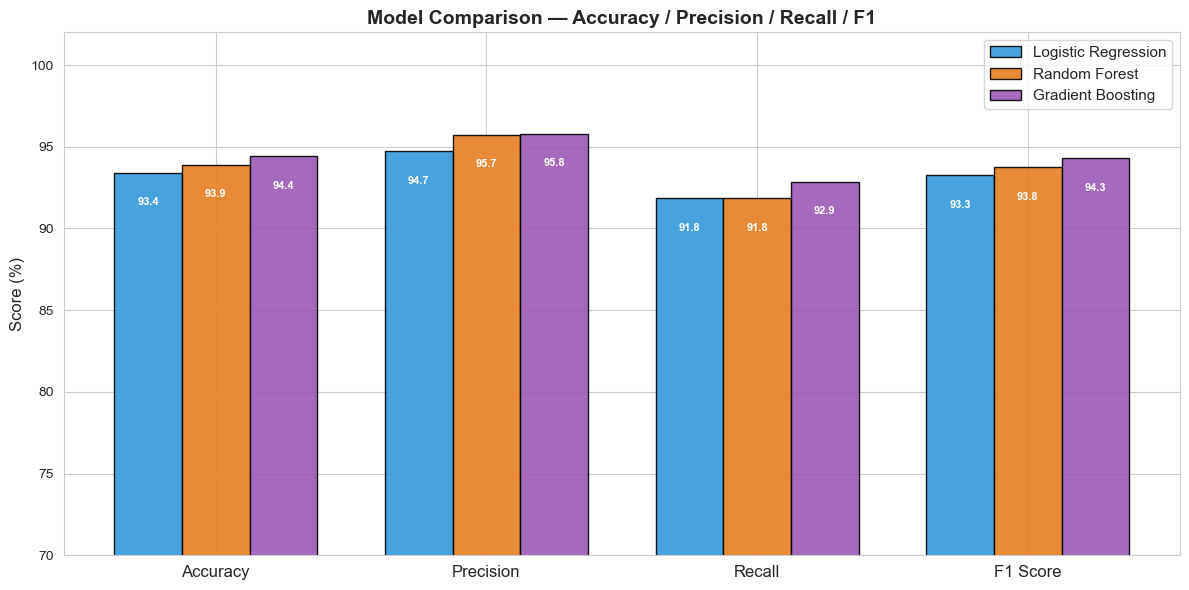

In [14]:
# ---- Plot 4: Model Comparison — Accuracy / Precision / Recall / F1 ----
bar_metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x     = np.arange(len(bar_metrics))
width = 0.25
colors = ['#3498db', '#e67e22', '#9b59b6']

fig, ax = plt.subplots(figsize=(12, 6))

# Plot grouped bars for each model
for i, (model_name, row) in enumerate(metrics_df.iterrows()):
    vals = [row[m] for m in bar_metrics]
    bars = ax.bar(x + i * width, vals, width, label=model_name, color=colors[i],
                  edgecolor='black', alpha=0.9)
    # Annotate each bar with its value
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 1.5,
                f'{bar.get_height():.1f}', ha='center', va='top',
                fontsize=8, fontweight='bold', color='white')

ax.set_xticks(x + width)
ax.set_xticklabels(bar_metrics, fontsize=12)
ax.set_ylim(70, 102)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Model Comparison — Accuracy / Precision / Recall / F1', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

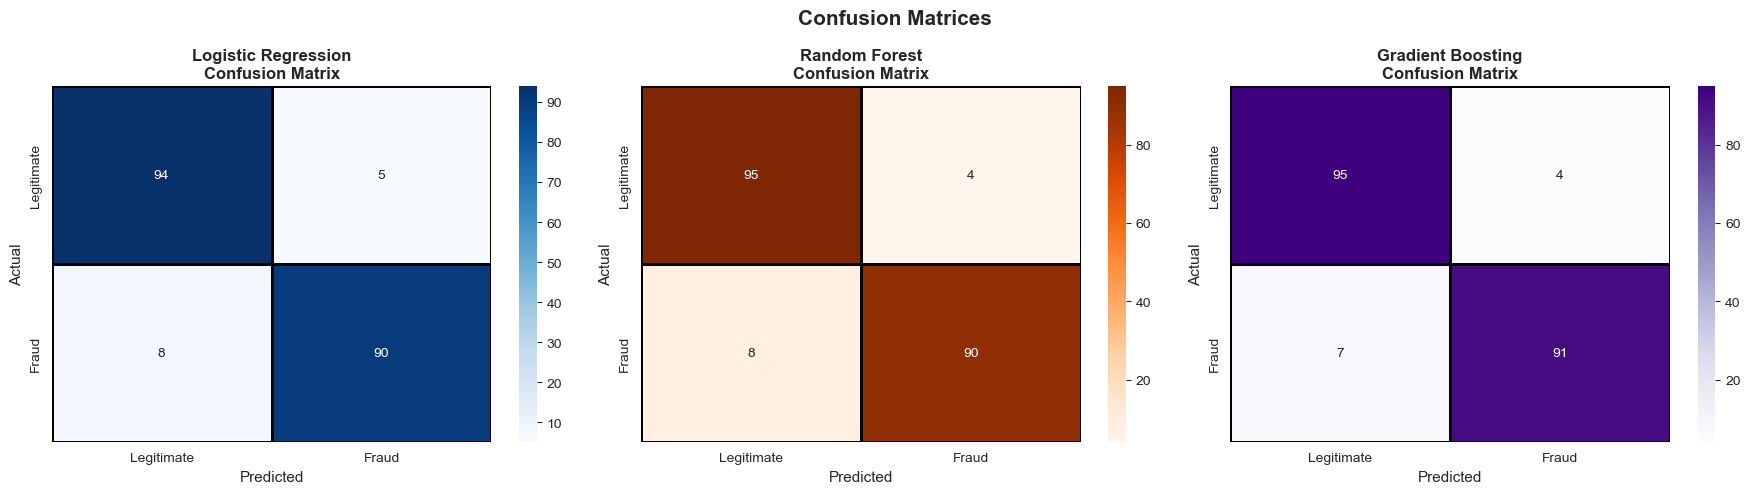

In [15]:
# ---- Plot 5: Confusion Matrices ----
# Shows True Positives, False Positives, True Negatives, False Negatives for each model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_info = [
    (lr_pred, 'Logistic Regression', 'Blues'),
    (rf_pred, 'Random Forest',       'Oranges'),
    (gb_pred, 'Gradient Boosting',   'Purples'),
]

for ax, (pred, title, cmap) in zip(axes, model_info):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Legitimate', 'Fraud'],
                yticklabels=['Legitimate', 'Fraud'],
                linewidths=1, linecolor='black')
    ax.set_title(f'{title}\nConfusion Matrix', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)

plt.suptitle('Confusion Matrices', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

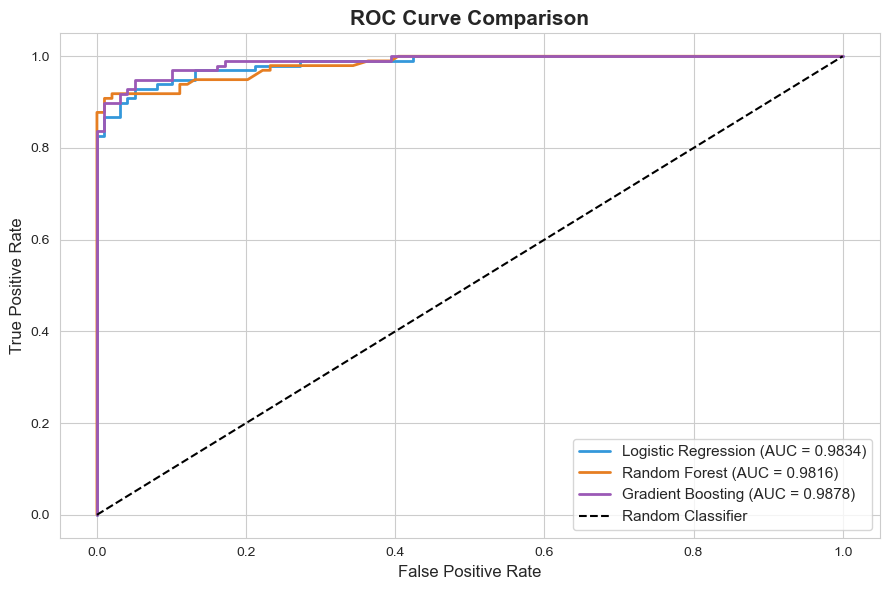

In [16]:
# ---- Plot 6: ROC Curves ----
# ROC curve plots True Positive Rate vs False Positive Rate at all classification thresholds
# AUC (Area Under the Curve) closer to 1.0 means better model performance
plt.figure(figsize=(9, 6))

for proba, name, color in [
    (lr_proba, 'Logistic Regression', '#3498db'),
    (rf_proba, 'Random Forest',       '#e67e22'),
    (gb_proba, 'Gradient Boosting',   '#9b59b6'),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', color=color, linewidth=2)

# Diagonal line = random classifier (AUC = 0.5)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=15, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

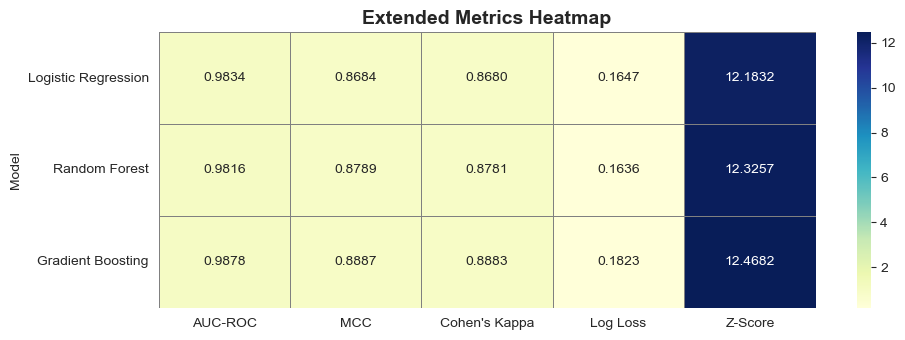

In [17]:
# ---- Plot 7: Extended Metrics Heatmap ----
# Visualises AUC, MCC, Kappa, Log Loss, Z-Score side by side for easy comparison
# Lower Log Loss is better; higher values are better for all other metrics shown
heatmap_cols = ['AUC-ROC', 'MCC', "Cohen's Kappa", 'Log Loss', 'Z-Score']
hm_data = metrics_df[heatmap_cols].astype(float)

plt.figure(figsize=(10, 3.5))
sns.heatmap(hm_data, annot=True, fmt='.4f', cmap='YlGnBu',
            linewidths=0.5, linecolor='grey')
plt.title('Extended Metrics Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

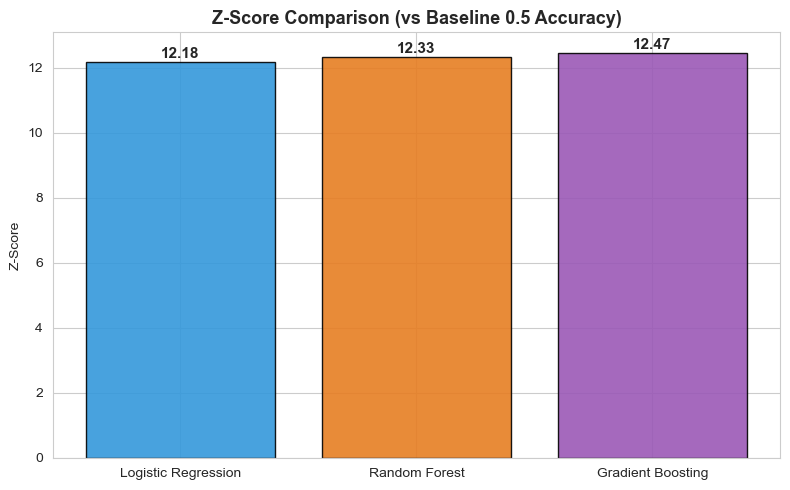

In [18]:
# ---- Plot 8: Z-Score Comparison ----
# Z-Score measures how many standard deviations the model accuracy is above
# a random baseline (0.5). Higher Z-Score = more statistically significant result.
zscore_vals = metrics_df['Z-Score'].values
model_names = metrics_df.index.tolist()
colors      = ['#3498db', '#e67e22', '#9b59b6']

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, zscore_vals, color=colors, edgecolor='black', alpha=0.9)

# Annotate each bar
for bar, v in zip(bars, zscore_vals):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
             f'{v:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.title('Z-Score Comparison (vs Baseline 0.5 Accuracy)', fontsize=13, fontweight='bold')
plt.ylabel('Z-Score')
plt.tight_layout()
plt.show()

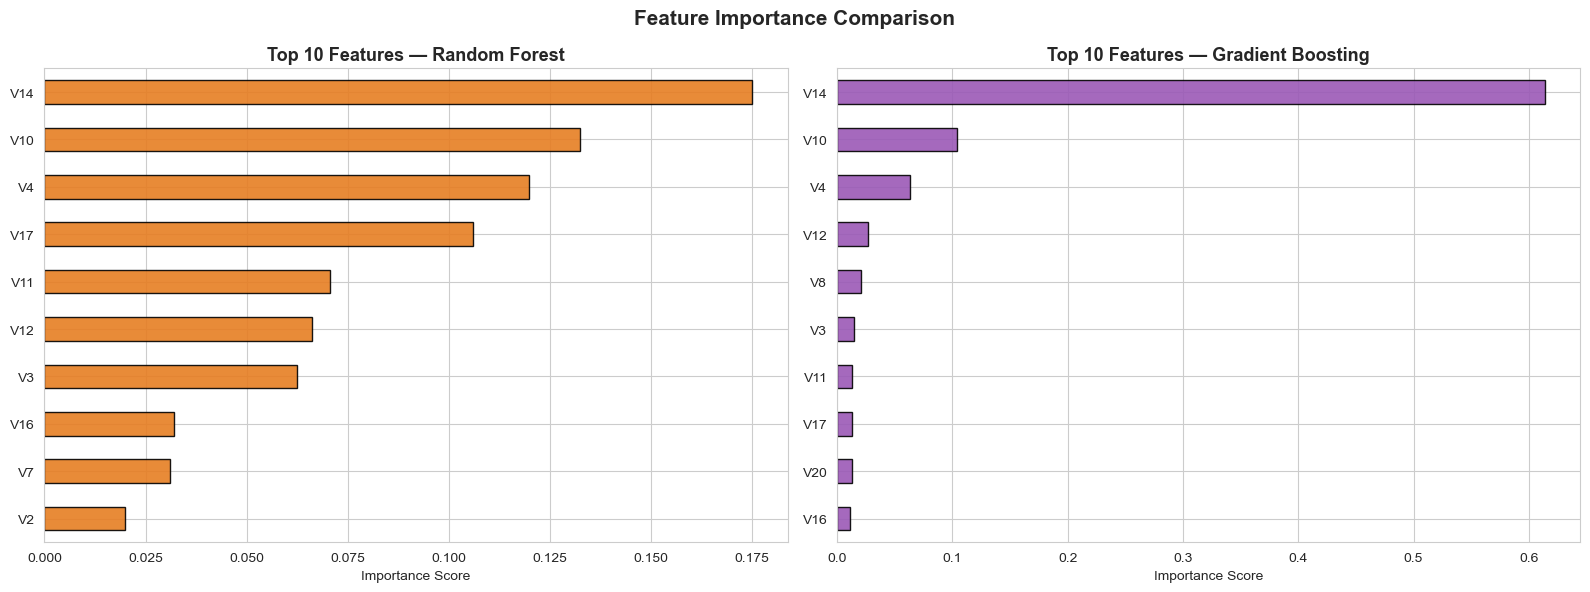

In [19]:
# ---- Plot 9: Feature Importance Comparison ----
# Both tree-based models can rank features by how much they reduce impurity
# Top features are the most useful for distinguishing fraud from legitimate transactions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, model, name, color in [
    (axes[0], rf_model, 'Random Forest',     '#e67e22'),
    (axes[1], gb_model, 'Gradient Boosting', '#9b59b6'),
]:
    feat_imp = pd.Series(model.feature_importances_, index=X.columns)
    top10 = feat_imp.nlargest(10).sort_values()   # top 10 most important features
    top10.plot(kind='barh', ax=ax, color=color, edgecolor='black', alpha=0.9)
    ax.set_title(f'Top 10 Features — {name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance Score')

plt.suptitle('Feature Importance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Testing with New Samples

In [20]:
# Pick sample transactions from the TEST set to demonstrate real-world usage
# Pick 5 samples: 3 fraud + 2 legitimate
fraud_samples = X_test[y_test == 1].head(3)
legit_samples = X_test[y_test == 0].head(2)
new_samples   = pd.concat([fraud_samples, legit_samples])
actual_labels = pd.concat([y_test[y_test == 1].head(3), y_test[y_test == 0].head(2)])

# Predict using Random Forest (best model)
best_pred  = rf_model.predict(new_samples)
best_proba = rf_model.predict_proba(new_samples)[:, 1]   # fraud probability

# Display results in a readable table
results_tbl = pd.DataFrame({
    'Actual'         : ['Fraud' if x == 1 else 'Legitimate' for x in actual_labels],
    'Predicted'      : ['Fraud' if x == 1 else 'Legitimate' for x in best_pred],
    'Fraud Prob (%)' : (best_proba * 100).round(2),
    'Correct?'       : ['Yes' if a == p else 'No' for a, p in zip(actual_labels, best_pred)]
})

print(results_tbl.to_string(index=False))

    Actual  Predicted  Fraud Prob (%) Correct?
     Fraud      Fraud            99.5      Yes
     Fraud      Fraud           100.0      Yes
     Fraud      Fraud            73.0      Yes
Legitimate Legitimate             3.0      Yes
Legitimate Legitimate             3.5      Yes


In [21]:
# Predict a completely custom transaction
# Use the mean feature values of all fraud transactions as a synthetic example
custom_transaction = fraud_df.drop(columns=['Class']).mean().values.reshape(1, -1)

# Run prediction using Random Forest
custom_pred  = rf_model.predict(custom_transaction)
custom_prob  = rf_model.predict_proba(custom_transaction)[0][1]

result = 'FRAUD DETECTED' if custom_pred[0] == 1 else 'Legitimate Transaction'
print(f"Custom Transaction Prediction : {result}")
print(f"Fraud Probability             : {custom_prob * 100:.2f}%")

Custom Transaction Prediction : FRAUD DETECTED
Fraud Probability             : 100.00%


## Final Summary

In [22]:
header_metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score',
                  'AUC-ROC', 'MCC', "Cohen's Kappa", 'Log Loss', 'Z-Score']

col_w = 22
sep   = "=" * (col_w + len(metrics_df.index) * 20)
print(sep)
print("CREDIT CARD FRAUD DETECTION — FINAL RESULTS SUMMARY".center(len(sep)))
print(sep)
print(f"Dataset           : creditcard.csv (Kaggle)")
print(f"Total Samples     : {df.shape[0]:,}")
print(f"Fraud Cases       : {df['Class'].sum():,} ({df['Class'].mean()*100:.2f}%)")
print(f"Balanced Dataset  : {balanced_df.shape[0]} samples")
print(f"Train / Test Split: 80% / 20%  |  Stratified")
print()

# Print all metrics per model
header = f"{'Metric':<{col_w}}" + "".join(f"{m:>20}" for m in metrics_df.index)
print(header)
print("-" * len(header))
for metric in header_metrics:
    row_str = f"{metric:<{col_w}}" + "".join(f"{metrics_df.loc[m, metric]:>20.4f}" for m in metrics_df.index)
    print(row_str)

print(sep)

# --- Best Model Selection via Weighted Composite Score ---
# Using multiple key metrics with different weights to reflect fraud-detection priorities:
#   F1 Score  (0.30) — balances precision and recall, critical for imbalanced problems
#   AUC-ROC   (0.25) — measures ranking ability across all classification thresholds
#   Recall    (0.20) — catching actual fraud is high priority (minimise false negatives)
#   MCC       (0.15) — most reliable single metric for imbalanced class problems
#   Precision (0.10) — avoiding false alarms matters, but less so than missing real fraud

# Normalise percentage-based metrics to [0, 1] before applying weights
norm = metrics_df[['F1 Score', 'AUC-ROC', 'Recall', 'MCC', 'Precision']].copy()
norm['F1 Score']  = norm['F1 Score']  / 100
norm['Recall']    = norm['Recall']    / 100
norm['Precision'] = norm['Precision'] / 100
# AUC-ROC and MCC are already in [0, 1] range

weights = {'F1 Score': 0.30, 'AUC-ROC': 0.25, 'Recall': 0.20, 'MCC': 0.15, 'Precision': 0.10}
composite_score = sum(norm[m] * w for m, w in weights.items())

print()
print(f"{'Model':<25} {'Composite Score':>18}")
print("-" * 44)
for model_name, score in composite_score.items():
    print(f"{model_name:<25} {score:>18.4f}")

best_model = composite_score.idxmax()
print(sep)
print(f"Best Model (Weighted Composite Score): {best_model}")
print(sep)

               CREDIT CARD FRAUD DETECTION — FINAL RESULTS SUMMARY                
Dataset           : creditcard.csv (Kaggle)
Total Samples     : 284,807
Fraud Cases       : 492 (0.17%)
Balanced Dataset  : 984 samples
Train / Test Split: 80% / 20%  |  Stratified

Metric                 Logistic Regression       Random Forest   Gradient Boosting
----------------------------------------------------------------------------------
Accuracy                           93.4010             93.9086             94.4162
Precision                          94.7368             95.7447             95.7895
Recall                             91.8367             91.8367             92.8571
F1 Score                           93.2642             93.7500             94.3005
AUC-ROC                             0.9834              0.9816              0.9878
MCC                                 0.8684              0.8789              0.8887
Cohen's Kappa                       0.8680              0.8781         